### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [100]:
data = pd.read_csv('data/coupons.csv')

In [101]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [102]:
#data.info()
data.isna().sum()
#data.isna().sum().sum()
#data.duplicated().sum()
#data.describe()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [103]:
#Drop car column as it has no value on data set and have NaN for 12576 rows
data = data.drop(columns=['car'])

#Use the most common value for below column to replace NaN
cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in cols:
    data[col] = data[col].fillna(data[col].mode()[0])

#It will show non of the columns have NaN and data cleaning completed.
data.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [104]:
data['Y'].mean()
#data['Y'].sum() / len(data) -- manual way answer remain same - 56% proportion accepted the coupon.

np.float64(0.5684326710816777)

5. Use a bar plot to visualize the `coupon` column.

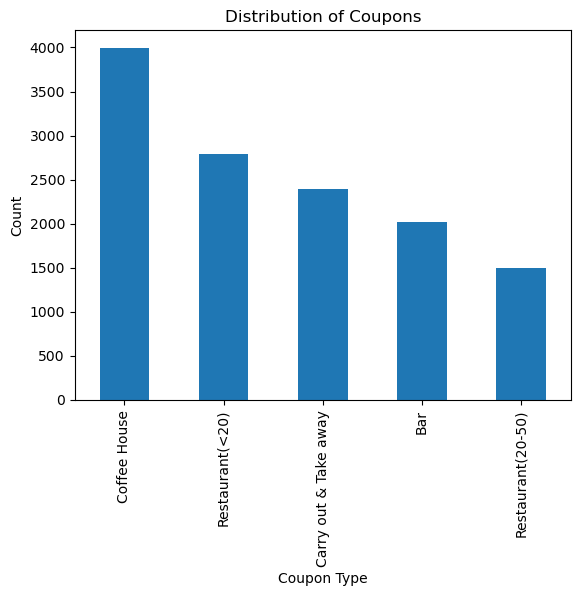

In [105]:
data['coupon'].value_counts().plot(kind='bar')
plt.xlabel("Coupon Type")
plt.ylabel("Count")
plt.title("Distribution of Coupons")
plt.savefig("/Users/rahulrusia/Downloads/assignment5_1_starter/images/Distribution_of_Coupons.png")
plt.show()

6. Use a histogram to visualize the temperature column.

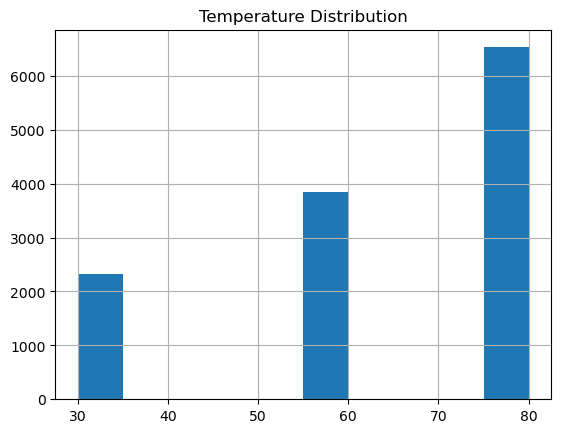

In [106]:
data['temperature'].hist()
plt.title("Temperature Distribution")
plt.savefig("/Users/rahulrusia/Downloads/assignment5_1_starter/images/temperature_histogram.png")
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [107]:
bar_coupons = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [108]:
bar_coupons['Y'].mean()

np.float64(0.41001487357461575)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [109]:
less_equal_3 = bar_coupons[bar_coupons['Bar'].isin(['less1', '1~3'])]
less_equal_3 =less_equal_3['Y'].mean()
print("Acceptance rate for ≤3 visits/month:", less_equal_3)

more_than_3 = bar_coupons[bar_coupons['Bar'].isin(['4~8','gt8'])]
more_than_3 = more_than_3['Y'].mean()
print("Acceptance rate for >3 visits/month:", more_than_3)

if less_equal_3 > more_than_3:
    print("People who visit the bar 3 or fewer times per month are using coupons more.")
elif more_than_3 > less_equal_3:
    print("People who visit the bar more than 3 times per month are using coupons more.")
else:
    print("Both groups are using coupons equally.")


Acceptance rate for ≤3 visits/month: 0.5274043433298863
Acceptance rate for >3 visits/month: 0.7688442211055276
People who visit the bar more than 3 times per month are using coupons more.


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [110]:
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['age'] != '21') &
    (bar_coupons['age'] != 'below21')
]

group1_rate = group1['Y'].mean()
print("Acceptance rate (Bar >1/month & age >25):", group1_rate)

group2 = bar_coupons.drop(group1.index)

group2_rate = group2['Y'].mean()
print("Acceptance rate (All other drivers):", group2_rate)

if group1_rate > group2_rate:
    print("Drivers who go to bars more than once a month and are over 25 accept coupons more often.")
elif group2_rate > group1_rate:
    print("Other drivers accept coupons more often.")
else:
    print("Both groups accept coupons at the same rate.")

Acceptance rate (Bar >1/month & age >25): 0.6952380952380952
Acceptance rate (All other drivers): 0.33500313087038197
Drivers who go to bars more than once a month and are over 25 accept coupons more often.


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [111]:
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]

group1_rate = group1['Y'].mean()
print("Acceptance rate (target group):", group1_rate)

group2 = bar_coupons.drop(group1.index)

group2_rate = group2['Y'].mean()
print("Acceptance rate (all other drivers):", group2_rate)

if group1_rate > group2_rate:
    print("Drivers who go to bars more than once a month, have no kid passengers, and work outside farming/fishing/forestry accept coupons more often.")
elif group2_rate > group1_rate:
    print("Other drivers accept coupons more often.")
else:
    print("Both groups accept coupons at the same rate.")

Acceptance rate (target group): 0.7132486388384754
Acceptance rate (all other drivers): 0.296043656207367
Drivers who go to bars more than once a month, have no kid passengers, and work outside farming/fishing/forestry accept coupons more often.


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [112]:
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
]

rate1 = group1['Y'].mean()
print("Acceptance rate (Group 1) who go to bars more than once a month, had passengers that were not a kid, and were not widowed OR :", rate1)

group2 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['age'].isin(['below21','21','26']))
]

rate2 = group2['Y'].mean()
print("Acceptance rate (Group 2) go to bars more than once a month and are under the age of 30 OR :", rate2)

group3 = bar_coupons[
    (bar_coupons['RestaurantLessThan20'].isin(['4~8','gt8'])) &
    (bar_coupons['income'].isin([
        'Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999'
    ]))
]

rate3 = group3['Y'].mean()
print("Acceptance rate (Group 3) go to cheap restaurants more than 4 times a month and income is less than 50K.:", rate3)


Acceptance rate (Group 1) who go to bars more than once a month, had passengers that were not a kid, and were not widowed OR : 0.7132486388384754
Acceptance rate (Group 2) go to bars more than once a month and are under the age of 30 OR : 0.7217391304347827
Acceptance rate (Group 3) go to cheap restaurants more than 4 times a month and income is less than 50K.: 0.45348837209302323


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [113]:
print("""Hypothesis --> Drivers who frequently visit bars are significantly more likely to accept bar coupons. 
Their behavior suggests that people who already have a habit of going to bars are more receptive to promotions related to bars.""")

Hypothesis --> Drivers who frequently visit bars are significantly more likely to accept bar coupons. 
Their behavior suggests that people who already have a habit of going to bars are more receptive to promotions related to bars.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [114]:
#Create a DataFrame for Coffee House coupons
coffee_df = data[data['coupon'] == 'Coffee House']

In [115]:
#Check overall acceptance rate
coffee_df['Y'].mean()

np.float64(0.49924924924924924)

In [116]:
#Compare acceptance by passenger type
coffee_df.groupby('passanger')['Y'].mean()

passanger
Alone        0.437943
Friend(s)    0.596906
Kid(s)       0.483092
Partner      0.570492
Name: Y, dtype: float64

In [117]:
#Compare acceptance by age
coffee_df.groupby('age')['Y'].mean()

age
21         0.524349
26         0.514828
31         0.476726
36         0.467662
41         0.501538
46         0.513636
50plus     0.420183
below21    0.696774
Name: Y, dtype: float64

In [118]:
#Compare acceptance by time of day
coffee_df.groupby('time')['Y'].mean()

time
10AM    0.640712
10PM    0.424242
2PM     0.547859
6PM     0.412626
7AM     0.445783
Name: Y, dtype: float64